#Analisa Data Properti Rumah

## Menghubungkan google collab ke drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = "/content/drive/MyDrive/Colab Notebooks/data_set/Data_Properti_Rumah.xlsx"

## Persebaran Data Belanja

In [4]:
import pandas as pd
df = pd.read_excel(file_path, usecols=[
    "ID",
    "CUSTOMER_ID",
    "Tahun Jual",
    "Bulan Jual",
    "Tipe Properti",
    "Luas Properti (m2)",
    "# Kamar Tidur",
    "# Kamar Mandi",
    "Kolam Renang",
    "GYM",
    "Kota_Fix",
    "Jarak ke Stasiun KRL Terdekat (km)",
    "Harga",
    "Status",
    "Tipe Customer"
])
df.head()

,ID,CUSTOMER_ID,Tahun Jual,Bulan Jual,Tipe Properti,Luas Properti (m2),# Kamar Tidur,# Kamar Mandi,Kolam Renang,GYM,Kota_Fix,Jarak ke Stasiun KRL Terdekat (km),Harga,Status,Tipe Customer
0,9,CUST-0044,2016,6,Apartment,72.673558,2,1,Tidak,Tidak,Tangerang,3.094343,1.474673e+09,Terjual,Individual
1,87,CUST-0079,2017,8,Apartment,53.860403,2,1,Tidak,Tidak,Jakarta,4.111006,9.513640e+08,Terjual,Individual
2,57,CUST-0121,2017,7,Apartment,105.171733,3,2,Tidak,Tidak,Tangerang,4.190350,1.927068e+09,Terjual,Individual
3,171,CUST-0139,2017,10,Apartment,72.563598,2,1,Tidak,Tidak,Jakarta,4.763530,1.171128e+09,Terjual,Individual
4,137,CUST-0157,2017,11,Apartment,74.163016,2,1,Tidak,Tidak,Jakarta,1.132433,1.278851e+09,Terjual,Individual


### Hitung Ukuran Pemusatan Data

#### Mean, Median, Modus

In [5]:
mean = df['Harga'].mean()
median = df['Harga'].median()
modus = df['Harga'].mode()

print('Rata rata Variabel Harga: ',mean)
print('Nilai Tengah Variabel Harga: ',median)
print('Nilai Modus Variabel Harga: ', modus[0])

Rata rata Variabel Harga:  1505212940.1067865
Nilai Tengah Variabel Harga:  1362067837.372
Nilai Modus Variabel Harga:  2555306977.08


### Hitung Ukuran Penyebaran Data

#### Min, Max, Standar Deviasi

In [6]:
min = df['Harga'].min()
max = df['Harga'].max()
standar_deviasi = df['Harga'].std()

print("Nilai Minimal Harga Properti: ", min)
print("Nilai Maximal Harga Properti: ", max)
print("Nilai Standar Deviasi Harga Properti: ", standar_deviasi)

Nilai Minimal Harga Properti:  852507587.382
Nilai Maximal Harga Properti:  2798554732.094
Nilai Standar Deviasi Harga Properti:  436207219.9881614


### Visualisasi Pendukung

#### Histogram

In [7]:
import matplotlib.pyplot as plt

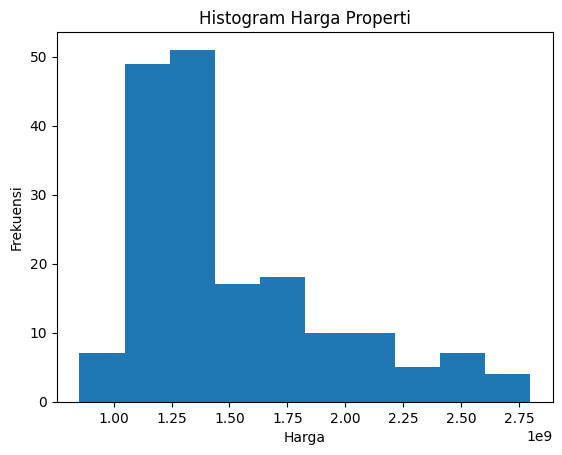

In [8]:
plt.hist(df['Harga'])
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.title('Histogram Harga Properti')
plt.show()

#### Boxplot

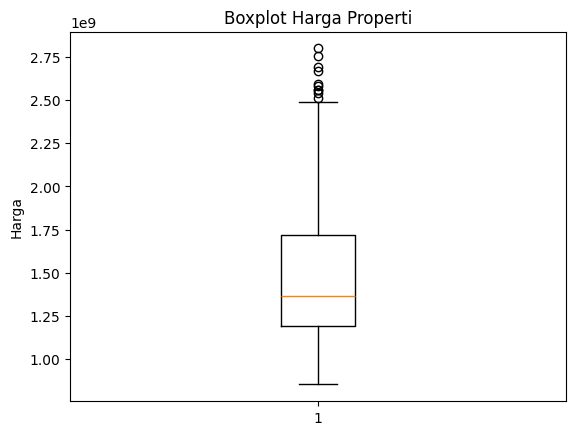

In [9]:
plt.boxplot(df['Harga'])
plt.title('Boxplot Harga Properti')
plt.ylabel('Harga')
plt.show()

### Menjawab Pertanyaan

Pertanyaan: Di kisaran harga berapakah mayoritas properti di pasar ini ditawarkan?

Jawaban: Mayoritas properti berada di kisaran 1.25 - 2.5 milliar, didukung oleh distribusi boxplot yang memperlihatkan data tersebar pada rentang tersebut, serta nilai median dan modus yang berada di sekitar 2 milliar

Apakah nilai rata-rata (mean) representatif untuk menggambarkan harga pasar secara umum, atau ada distorsi?

Nilai rata-rata(mean) kurang representatif karena distribusi harga properti bersifat skewed ke kanan, dengan adanya beberapa nilai ekstrim pada harga tinggi yang menarik rata-rata ke atas. Mayortias properti justru berada pada kisaran harga yang lebih rendah, sehingga median lebih mencerminkan kondisi pasar secara umum

## Korelasi`

#### Menentukan Variabel X dan Y

In [10]:
x = df['Luas Properti (m2)']
y = df['Harga']

#### Hitung Korelasi

In [11]:
x.corr(y)

np.float64(0.9388827060627041)

#### Visualisasi

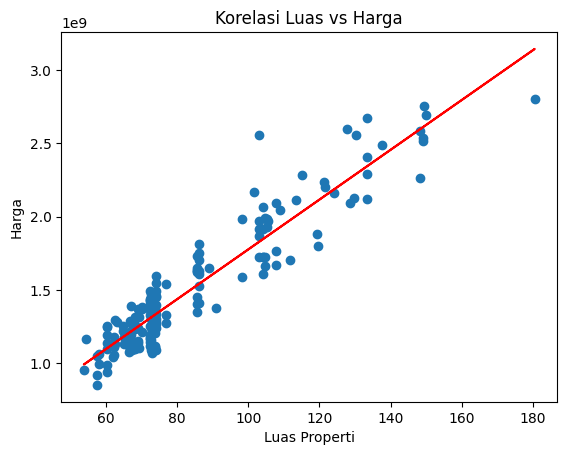

In [12]:
import numpy as np

m, b = np.polyfit(x, y, 1)

plt.scatter(x, y)
plt.plot(x, m*x + b, color='red')
plt.xlabel('Luas Properti')
plt.ylabel('Harga')
plt.title('Korelasi Luas vs Harga')
plt.show()

### Menjawab Pertanyaan

Pertanyaan: Seberapa kuat pengaruh luas tanah/bangunan terhadap harga jual?
Jawaban: Nilai Korelasi sebesar 0.94 menunukkan hubungan positif yang sangat kuat antara luas properti dan harga jual. Artinya, semakin besar luas tanah atau bangunan harga cenderung meningkat secara signifikan



Pertanyaan: Apakah properti yang lebih luas selalu menjamin harga yang lebih tinggi secara linear?

Jawaban: Tidak selalu. walaupun korelasi sangat kuat namun berdasarkan visualisasi scatter plot, terdapat beberapa titik yang tidak tepat di garis. artinya ada properti yang luasnya besar tapi harga tidak setinggi yang diprediksi atau sebaliknya


## Expected Value

### Variabel Harga Rumah yang dibeli per orang

In [13]:
df_total = df.groupby('CUSTOMER_ID')['Harga'].sum().reset_index()
df_total.rename(columns={'Harga': 'total_harga'}, inplace=True)

In [14]:
df_total.head()

,CUSTOMER_ID,total_harga
0,CUST-0012,2.282731e+09
1,CUST-0013,1.274676e+09
2,CUST-0014,2.095977e+09
3,CUST-0015,2.293418e+09
4,CUST-0016,1.153115e+09


### Hitung Expected Value

In [15]:
expected_value = df_total['total_harga'].mean()
expected_value

np.float64(1728567118.3161807)

### Pertanyaan

Pertanyaan: Jika seorang agen properti memilih satu unit rumah secara acak dari daftar (listing) ini, berapakah Expected Value (nilai harapan) dari harga rumah tersebut?

Jawaban: Expected Value dari harga rumah adalah sekitar 1.7 milliar. Artinya jika satu rumah dipilih secara acak, maka secara rata-rata harga yang diharapkan berada di kisaran tersebut

## Distribusi Data

### Menggunakan Histogram

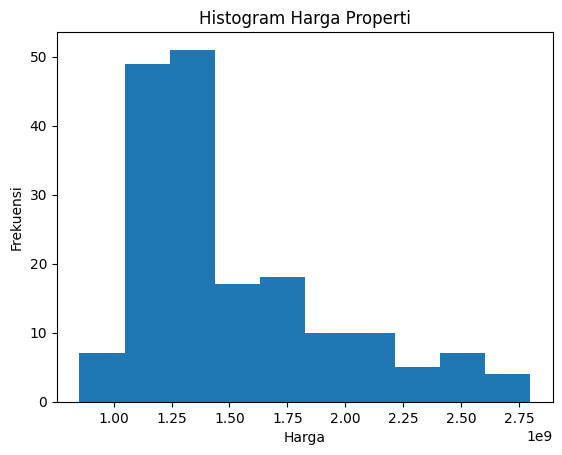

In [19]:
plt.hist(df['Harga'], 10)
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.title('Histogram Harga Properti')
plt.show()

### Amati skew

In [20]:
df['Harga'].skew()

np.float64(1.183763100764948)

### Menjawab Pertanyaan

Pertanyaan: Apakah distribusi harga rumah mengikuti kurva lonceng simetris (Distribusi Normal)?
Jawaban: Tidak karena berdasarkan pencarian skew dan juga gambar histogram. terlihat jelas ini disebut right skewed, bukan distribusi normal

Pertanyaan: Apa implikasinya bagi calon pembeli yang memiliki budget setara dengan nilai rata-rata (Mean)?
Jawaban: nilai rata-rata (mean) menjadi kurang representatif sebagai acuan bagi calon pembeli, karena cenderung lebih tinggi dibandingkan mayoritas harga properti. Oleh karena itu, median lebih tepat digunakan sebagai gambaran harga pasar secara umum.

## Reflection Question

Pertanyaan 1: Bagaimana pemahaman tentang distribusi harga (Skewness) dan ukuran pemusatan (Median vs Mean) dapat membantu Developer dalam menentukan strategi penetapan harga (pricing strategy) untuk peluncuran cluster perumahan baru? Mengapa menggunakan harga rata-rata (Mean) saja bisa berbahaya dalam menentukan target pasar?"

Jawaban: Pemahaman terhadap skewness dan perbandingan antara mean dan median sangat penting dalam menentukan strategi penetapan harga. Pada distribusi harga properti yang umumnya bersifat skewed ke kanan, nilai mean cenderung terdistorsi oleh sejumlah kecil properti dengan harga tinggi, sehingga tidak mencerminkan kondisi mayoritas pasar. Dalam hal ini, median lebih representatif untuk menggambarkan harga yang umum di pasar.

Dengan memahami hal tersebut, developer dapat menentukan harga yang lebih realistis dan sesuai dengan daya beli mayoritas konsumen, serta mengidentifikasi segmentasi pasar secara lebih akurat. Menggunakan mean saja dalam menentukan harga dapat berbahaya karena berpotensi menyebabkan overpricing, di mana harga yang ditetapkan terlalu tinggi dibandingkan kemampuan pasar, sehingga berdampak pada rendahnya penjualan dan meningkatnya risiko bisnis.

Pertanyaan 2: Dalam konteks investasi properti atau appraisal (penaksiran harga), bagaimana analisis Korelasi dapat membantu mendeteksi faktor penentu harga?

Jawaban: Analisis korelasi membantu dalam mendeteksi faktor penentu harga dengan mengukur kekuatan hubungan antara harga properti dan variabel-variabel terkait seperti luas, lokasi, dan fasilitas. Variabel dengan nilai korelasi tinggi menunjukkan pengaruh yang signifikan terhadap harga, sehingga dapat dijadikan dasar dalam proses appraisal maupun pengambilan keputusan investasi. Dengan demikian, analisis korelasi memungkinkan penilaian harga yang lebih objektif dan berbasis data. Namun, perlu diperhatikan bahwa korelasi tidak selalu menunjukkan hubungan sebab-akibat, sehingga hasil analisis tetap perlu dikombinasikan dengan pemahaman kontekstual terhadap pasar properti.